## DBSCAN 
不用指定 K
不假設群的形狀
用「密度」來定義群
# eps 太大 + min_samples 太小：
  → 所有點都變成同一群
  → 分不出任何結構

# eps 太小 + min_samples 太大：
  → 大部分點變成「雜訊點」
  → 沒有任何群被找到
# 雜訊點（Noise Point）= -1
K-Means 每個點都一定屬於某個群
DBSCAN 不強迫每個點都歸群
密度不夠的點直接標記為 -1（雜訊）

# K-Means：只能找圓形的群 → 月牙形分錯
# DBSCAN：用密度找群 → 月牙形完美分開

# 優點：
  → 不需要指定 K
  → 可以找任意形狀的群
  → 自動標記雜訊點
  → 對異常值有抵抗力

# 缺點：
  → eps 和 min_samples 不好設定
  → 資料密度差異大時效果差
  → 高維資料效果不好

# 適合場景：
  → 資料形狀不規則
  → 需要找異常點
  → 不知道有幾群

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

plt.rcParams['font.family'] = 'Microsoft JhengHei'
plt.rcParams['axes.unicode_minus'] = False

from sklearn.datasets import make_moons

X, y = make_moons(n_samples=500, noise=0.05, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='Set1', alpha=0.6)
plt.title('原始資料（兩個彎月形）')
plt.show()



In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42)
labels_km = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_km, cmap='Set1', alpha=0.6)
plt.title('K-Means 分群結果')
plt.show()

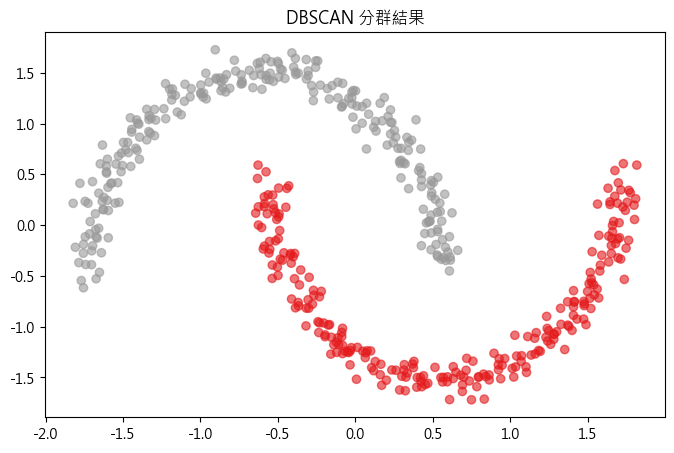

In [ ]:


dbscan = DBSCAN(eps=0.3, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)
plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_db,cmap='Set1', alpha=0.6)
plt.title('DBSCAN 分群結果')
plt.show()


In [5]:
n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = list(labels_db).count(-1)

print(f"找到幾群: {n_clusters}")
print(f"雜訊點數量: {n_noise}")

找到幾群: 2
雜訊點數量: 0


雜訊點數量: 22


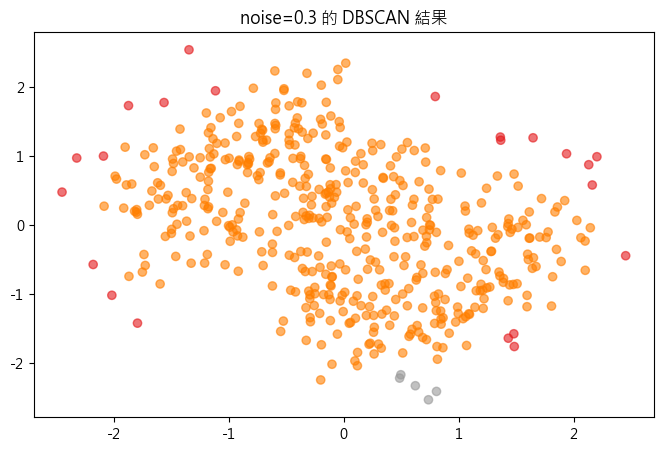

In [6]:
X_noisy, _ = make_moons(n_samples=500, noise=0.3, random_state=42)
X_noisy_scaled = scaler.fit_transform(X_noisy)

dbscan2 = DBSCAN(eps=0.3, min_samples=5)
labels_noisy = dbscan2.fit_predict(X_noisy_scaled)

n_noise2 = list(labels_noisy).count(-1)
print(f"雜訊點數量: {n_noise2}")

plt.figure(figsize=(8, 5))
plt.scatter(X_noisy_scaled[:, 0], X_noisy_scaled[:, 1], 
            c=labels_noisy, cmap='Set1', alpha=0.6)
plt.title('noise=0.3 的 DBSCAN 結果')
plt.show()